<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

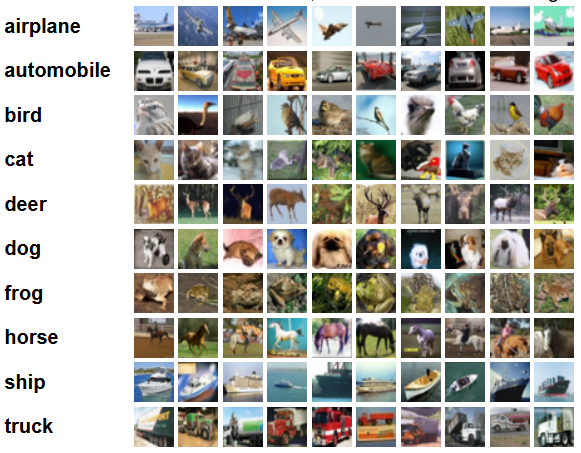

In [3]:
# Your code to import matplotlib, pandas and numpy libraries
#
# ...
# ...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models


##### Following code loads the CIFAR 10 datset.

___________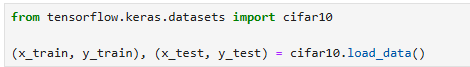

In [4]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train),(x_test, y_test) = cifar10.load_data()

In [5]:
# Your code to print shapes of training and test data. Check how the data looks

# ...
# ...
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
print( train_images.shape) 
print( train_labels.shape) 
print( test_images.shape)    
print( test_labels.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [6]:
# Your code to print the shape of one image

# ...
print( train_images[0].shape)


(32, 32, 3)


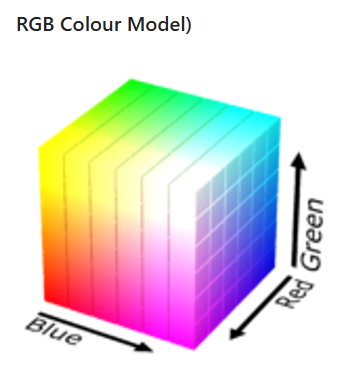

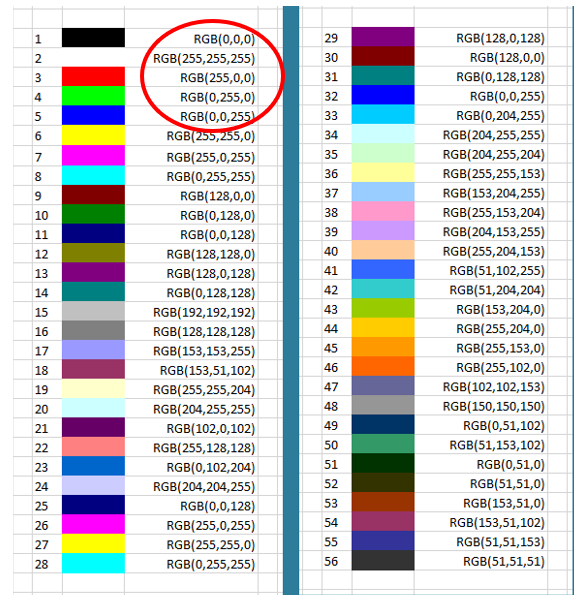

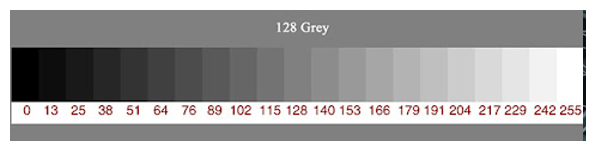

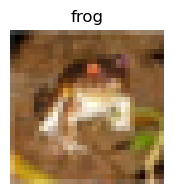

In [7]:
# Your code to show any sample image in the dataset. Use - plt.imshow()

# ...
# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Choose an index for the image you want to display
image_index = 0 

# Show the image using matplotlib
plt.figure(figsize=(2,2))
plt.imshow(train_images[image_index])
plt.title(class_names[train_labels[image_index][0]])
plt.axis('off') # Hide the axes
plt.show()


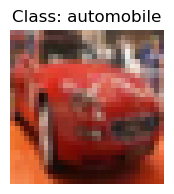

In [8]:
# Show any other image

# ...
# 
image_index = 5 
plt.figure(figsize=(2,2))
plt.imshow(train_images[image_index])
plt.title(f"Class: {class_names[train_labels[image_index][0]]}")
plt.axis('off')
plt.show()


____________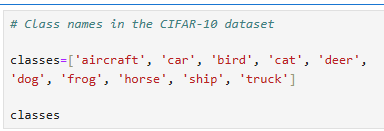

In [9]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______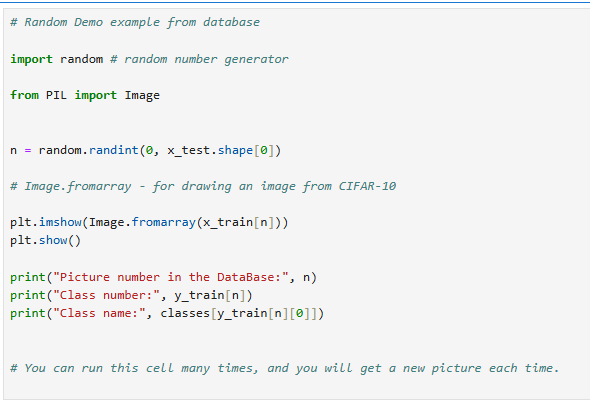

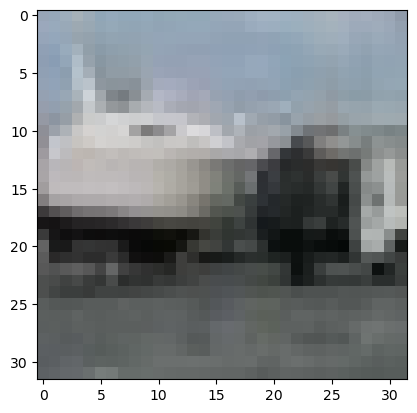

Picture number in the DataBase: 1821
Class number: [8]
Class name: ship


In [10]:
import random

from PIL import Image

n = random.randint(0, x_test.shape[0])

plt.imshow(Image.fromarray(x_train[n]))
plt.show()

print("Picture number in the DataBase:",n)
print("Class number:", y_train[n])
print("Class name:", classes[y_train[n][0]])

## PreProcessing

In [11]:
# Your code to print one image in digitals. Check what pixels look like. 

# ...
# 
sample_image = train_images[0]

print(sample_image)


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [12]:
# Your code to print the shape of any image i.e particular value in the x_train

# ...
# To print the shape of the image at index 100
print(train_images[100].shape)


(32, 32, 3)


In [13]:
# Your code to print the maximum value in x_train. Hint - Use .max()

# ...
print( train_images.max())

255


____________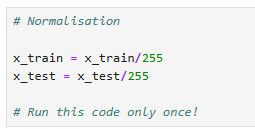

In [14]:
x_train = x_train/255
x_test = x_test/255

__________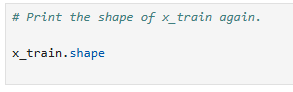

In [15]:
x_train.shape

(50000, 32, 32, 3)

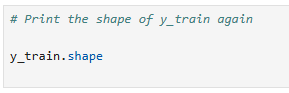

In [16]:
y_train.shape

(50000, 1)

## One hot vector encoding.
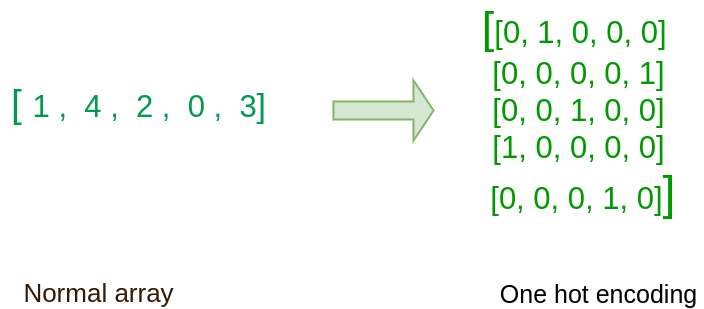


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________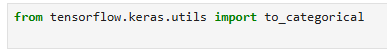

In [17]:
from tensorflow.keras.utils import to_categorical

___________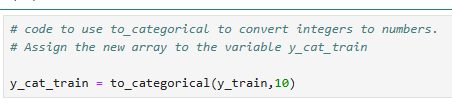

In [18]:
y_cat_train = to_categorical(y_train,10)

In [19]:
# Your code to print the shape of the array y_cat_train

# ...
print(y_cat_train.shape)

(50000, 10)


In [20]:
print(train_labels[index])

print(y_cat_train[index])


NameError: name 'index' is not defined

In [21]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

#  y_cat_test = ...


y_cat_test = to_categorical(test_labels, 10)

print("Shape of y_cat_test:", y_cat_test.shape) 

Shape of y_cat_test: (10000, 10)


____________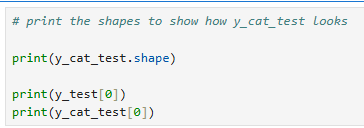

In [22]:
print(y_cat_test.shape)

print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________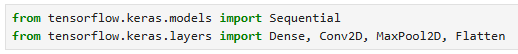

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D , Flatten

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [24]:
model = Sequential()

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4),input_shape=(32, 32, 3), activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# Add more convolution and pooling layers with your choice of filters, strides, and activation function
# ...
# ...

model.add(Flatten())

# Add a few dense layers. 
# ...
# ...




C:\Users\prath\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

model = Sequential()

# --- CONVOLUTIONAL BASE ---
# First Layer (already provided)
model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Second Layer: Increasing filters to capture more complex features
model.add(Conv2D(filters=64, kernel_size=(4,4), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# --- CLASSIFICATION HEAD ---
# Flatten the 2D feature maps into a 1D vector
model.add(Flatten())

# Dense Hidden Layer: 256 or 128 units are standard for CIFAR-10
model.add(Dense(256, activation='relu'))

# Final Output Layer: Must have 10 units (for 10 classes) 
# and 'softmax' activation for multi-class probability
model.add(Dense(10, activation='softmax'))


__________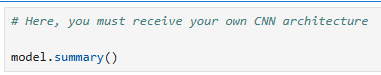

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,826 (1.70 MB)

 Trainable params: 446,826 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________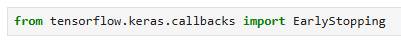

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

__________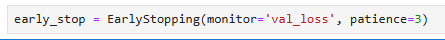

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [29]:
# Your code to compile the models (model.compile). 

# Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# You can use the optimiser of your choice

# ...
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [31]:
# Your code to fit the model (model.fit). 

# Use additional parameter -  callbacks = [early_stop] to enable early stopping. 
# Use 'history' array to save the training parameters for each epoch

# history = ...
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define Early Stopping
# monitor='val_loss': watch the validation loss
# patience=2: wait for 2 epochs of no improvement before stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# 2. Fit the model
# Using y_cat_train and y_cat_test (one-hot encoded labels)
history = model.fit(train_images, 
                    y_cat_train, 
                    epochs=20, 
                    validation_data=(test_images, y_cat_test),
                    callbacks=[early_stop])


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6818 - loss: 0.9207 - val_accuracy: 0.5830 - val_loss: 1.2787
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7136 - loss: 0.8272 - val_accuracy: 0.5802 - val_loss: 1.3720
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7509 - loss: 0.7244 - val_accuracy: 0.5822 - val_loss: 1.4727


______________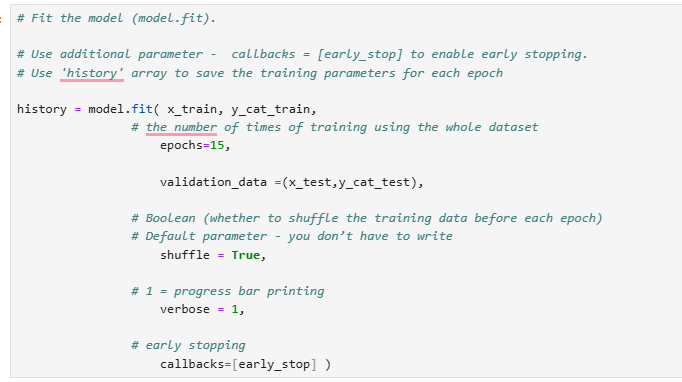

In [32]:
history = model.fit(x_train, 
                    y_cat_train, 
                    epochs=15, 
                    validation_data=(x_test, y_cat_test),
                    shuffle=True,
                    verbose = 1,
                    callbacks=[early_stop])
                

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.4420 - loss: 1.5352 - val_accuracy: 0.5427 - val_loss: 1.2750
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.5918 - loss: 1.1516 - val_accuracy: 0.6157 - val_loss: 1.0991
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6658 - loss: 0.9546 - val_accuracy: 0.6688 - val_loss: 0.9563
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7159 - loss: 0.8095 - val_accuracy: 0.6755 - val_loss: 0.9326
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7644 - loss: 0.6769 - val_accuracy: 0.6645 - val_loss: 1.0044
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8073 - loss: 0.5522 - val_accuracy: 0.6733 - val_loss: 1.0075


##### You can save the model in a file. Following code shows how to do this.

________________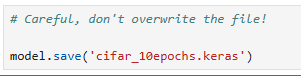

In [50]:
model.save('cifar_10epochs.keras') 

##### Yiu can save the loss at every step. Following code shows how to do this. 

___________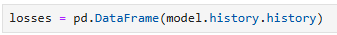

In [52]:
losses = pd.DataFrame(model.history.history)

In [56]:
# You code to print the first few rows of losses.

# ...

print(losses.head(7))

   accuracy      loss  val_accuracy  val_loss
0   0.43674  1.551840        0.5393  1.302866
1   0.60096  1.131240        0.6103  1.109840
2   0.67126  0.947144        0.6584  0.977070
3   0.71782  0.802468        0.6845  0.921552
4   0.76068  0.684137        0.6951  0.905569
5   0.80020  0.571843        0.6934  0.939451
6   0.83602  0.465487        0.6903  1.021322


,accuracy,loss,val_accuracy,val_loss
0,0.43480,1.560612,0.5303,1.349832
1,0.57198,1.201473,0.5538,1.219868
2,0.62928,1.049085,0.6245,1.049745
3,0.66792,0.944133,0.6840,0.951214
4,0.70052,0.851300,0.6653,1.013123
5,0.72508,0.783289,0.6328,1.247608
6,0.74762,0.724635,0.6821,1.093254


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs) 
#### y axis will have accuracy and val_accuracy 


_________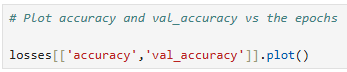

<Axes: >

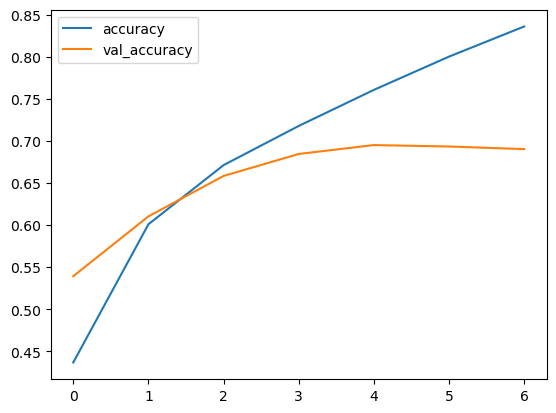

In [57]:
losses[['accuracy','val_accuracy']].plot()

<Axes: >

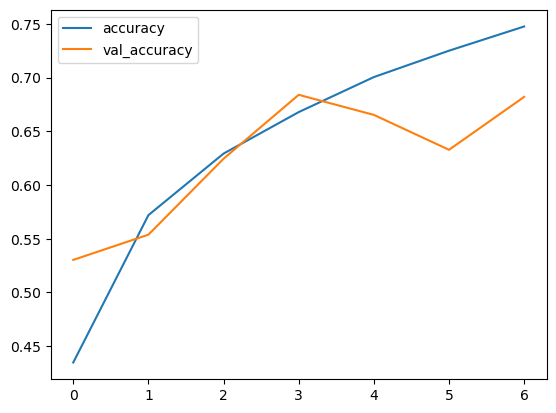

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

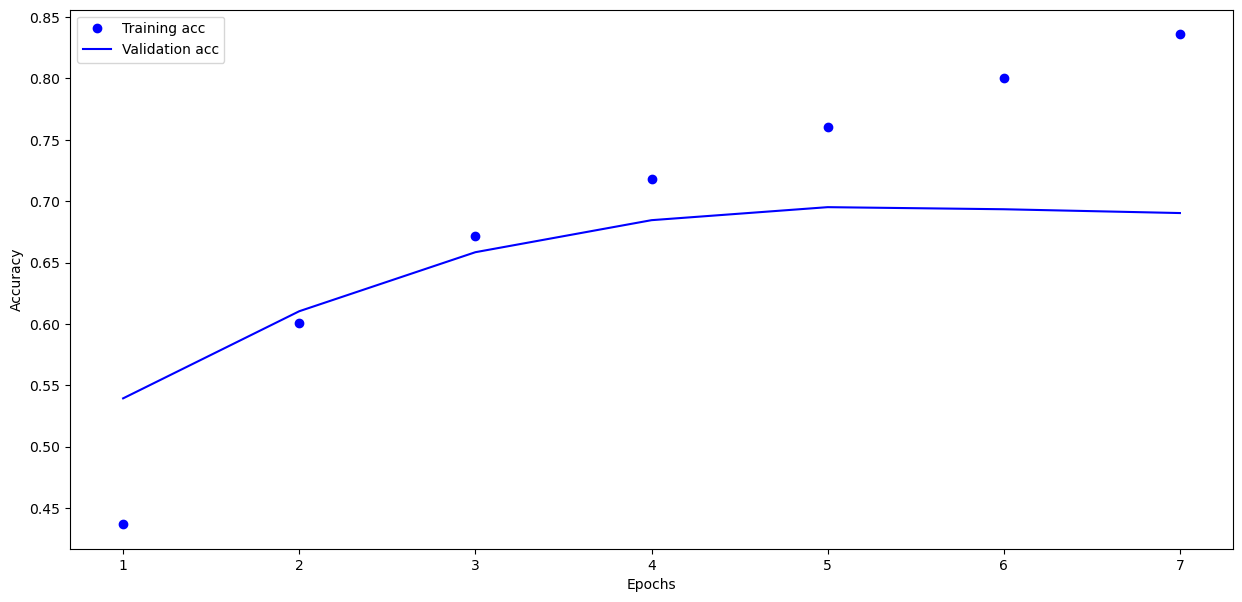

In [58]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

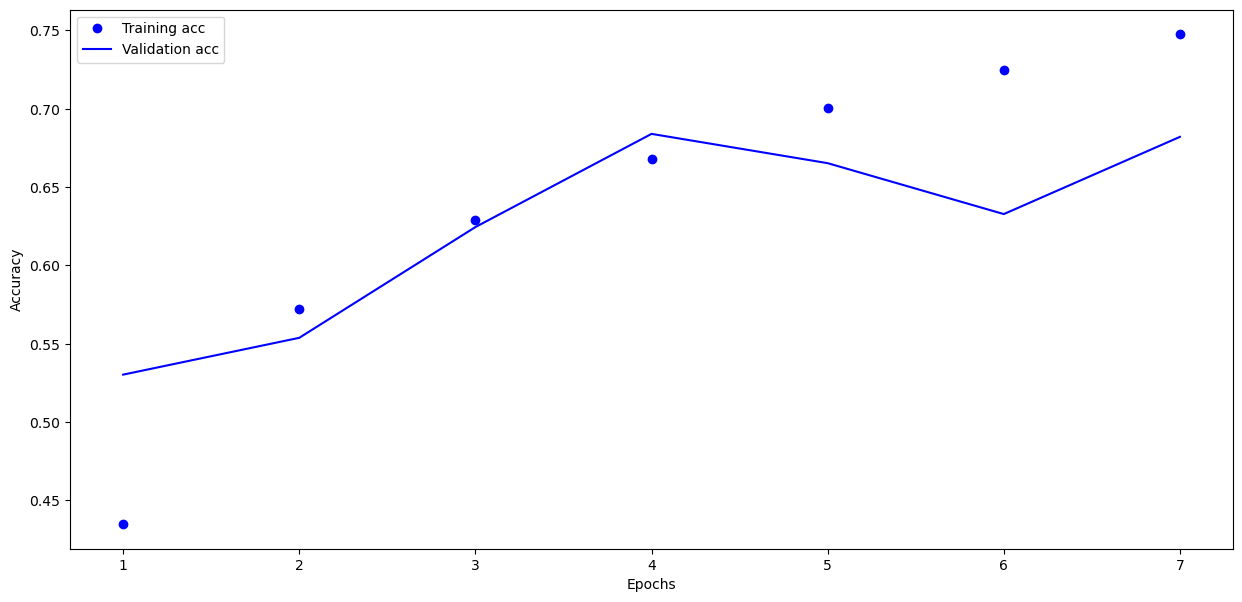

__________________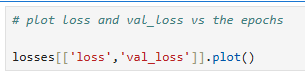

<Axes: >

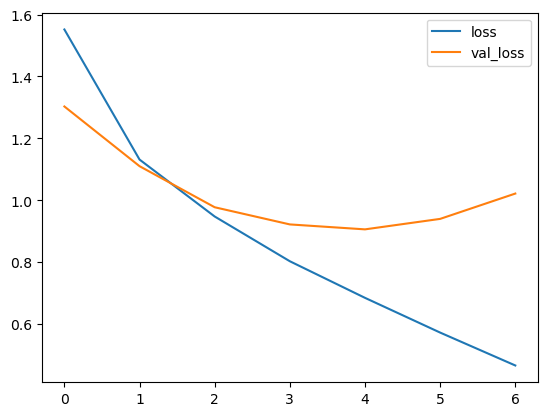

In [59]:
losses[['loss','val_loss']].plot()

<Axes: >

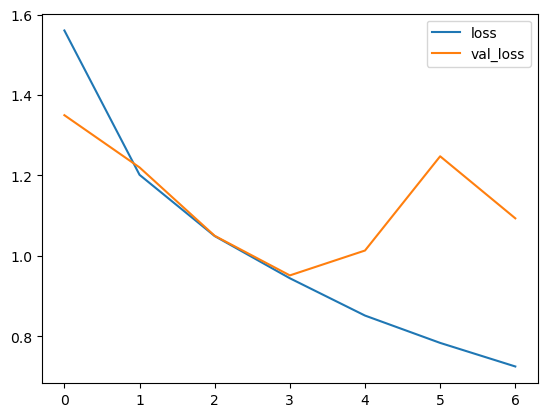

_____________________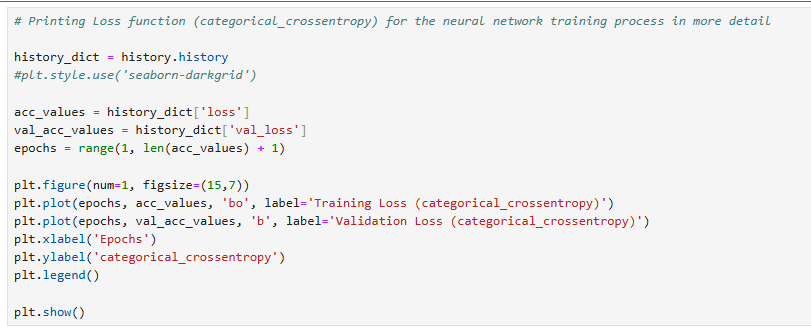

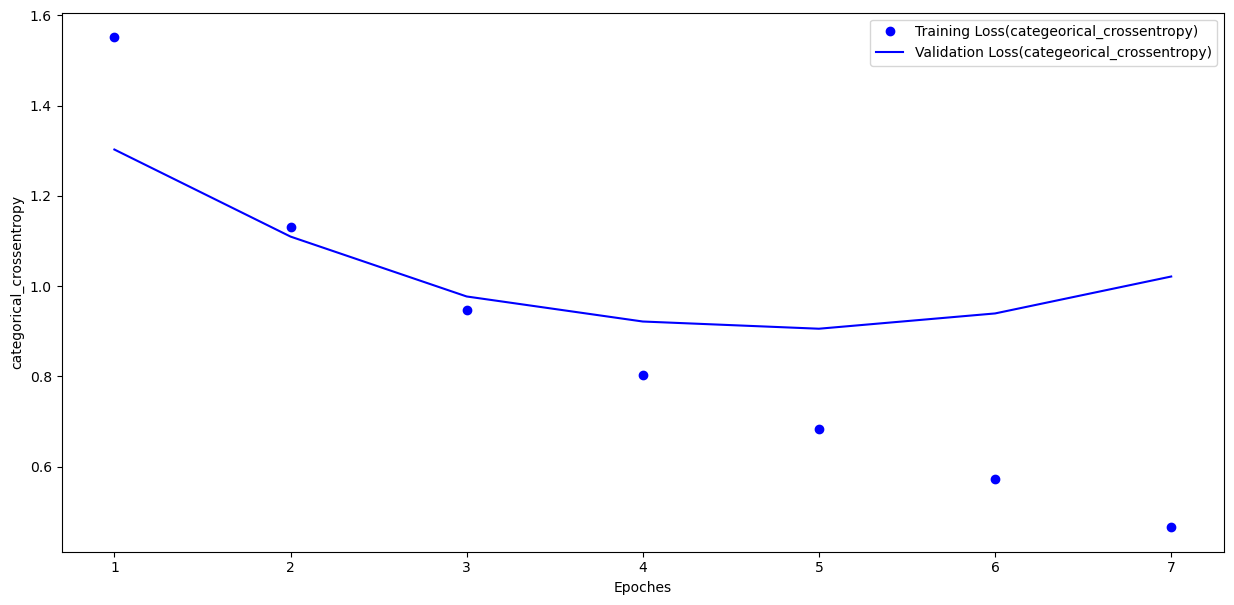

In [60]:
history_dict = history.history
acc_values=history_dict['loss']
val_acc_values=history_dict['val_loss']
epochs =range(1, len(acc_values)+1)
plt.figure(num=1,figsize=(15,7))
plt.plot(epochs,acc_values,'bo',label='Training Loss(categeorical_crossentropy)')
plt.plot(epochs,val_acc_values,'b',label='Validation Loss(categeorical_crossentropy)')
plt.xlabel('Epoches')
plt.ylabel('categorical_crossentropy')
plt.legend()
plt.show()


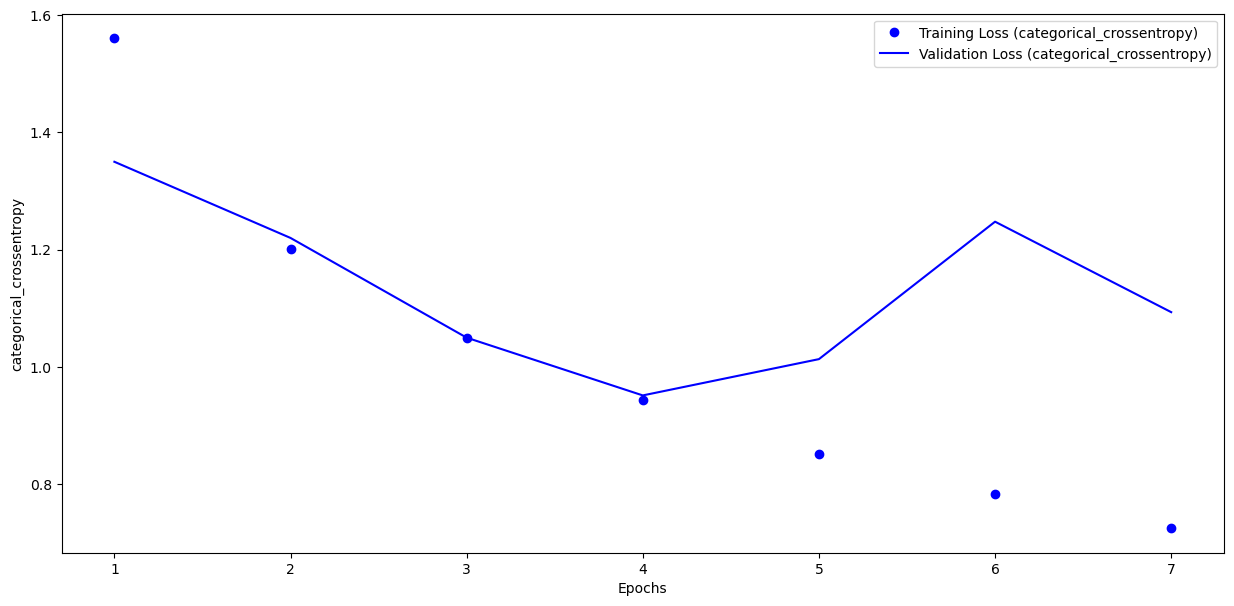

__________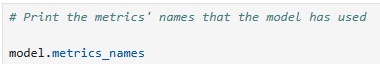

In [61]:
model.metrics_names

['loss', 'compile_metrics']

['loss', 'compile_metrics']

___________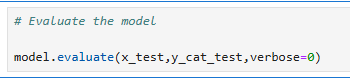

In [62]:
model.evaluate(x_test,y_cat_test,verbose=0) 

[1.02132248878479, 0.6902999877929688]

In [63]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

[1.02132248878479, 0.6902999877929688]

___________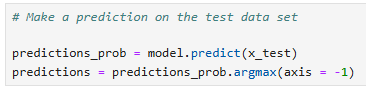

In [64]:
predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [110]:
# Make a prediction on the test data set

predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


_______________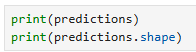

In [65]:
print(predictions)
print(predictions.shape)

[3 8 8 ... 5 1 7]
(10000,)


[3 8 1 ... 5 1 7]
(10000,)


##### You could get the full classification report. 

_____________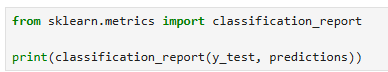

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73      1000
           1       0.78      0.84      0.81      1000
           2       0.62      0.53      0.57      1000
           3       0.50      0.53      0.51      1000
           4       0.66      0.65      0.66      1000
           5       0.63      0.52      0.57      1000
           6       0.66      0.84      0.74      1000
           7       0.82      0.67      0.74      1000
           8       0.81      0.77      0.79      1000
           9       0.78      0.76      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________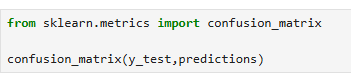

In [67]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,predictions)

array([[796,  27,  28,  17,  12,   4,  19,   7,  50,  40],
       [ 23, 844,   6,   8,   3,   2,  15,   2,  29,  68],
       [ 95,  13, 533,  74,  83,  54, 101,  20,  16,  11],
       [ 33,  16,  76, 528,  54, 142,  91,  25,  14,  21],
       [ 38,   8,  60,  68, 649,  24,  94,  37,  11,  11],
       [ 22,   6,  77, 198,  60, 522,  54,  40,   8,  13],
       [ 10,   5,  25,  56,  32,  15, 840,   6,   7,   4],
       [ 34,  11,  29,  67,  73,  58,  27, 670,   7,  24],
       [102,  45,   9,  20,   8,   8,  17,   3, 765,  23],
       [ 31, 106,  14,  22,   5,   6,  12,  11,  37, 756]])

array([[697,  33,  12,  17,  33,  20,  11,  15,  84,  78],
       [  8, 762,   1,   9,   1,   7,   7,   3,  18, 184],
       [ 77,   7, 378,  64, 190, 150,  53,  34,  17,  30],
       [ 21,  17,  14, 447, 117, 245,  32,  40,  20,  47],
       [ 14,   2,  11,  34, 760,  47,  19,  83,  12,  18],
       [  8,   4,  11, 106,  71, 717,  13,  40,   8,  22],
       [  7,   9,  21,  76, 107,  51, 684,   9,   8,  28],
       [ 13,   3,   8,  23,  74,  94,   3, 742,   5,  35],
       [ 62,  42,   4,  15,  12,  19,   3,   5, 748,  90],
       [  8,  47,   4,   7,   4,  15,   3,   7,  19, 886]], dtype=int64)

_______________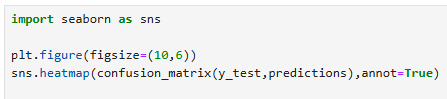

<Axes: >

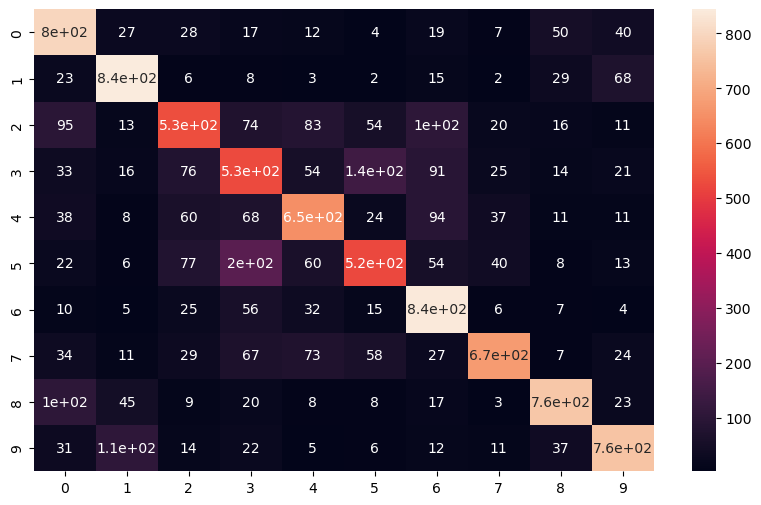

In [68]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)

<Axes: >

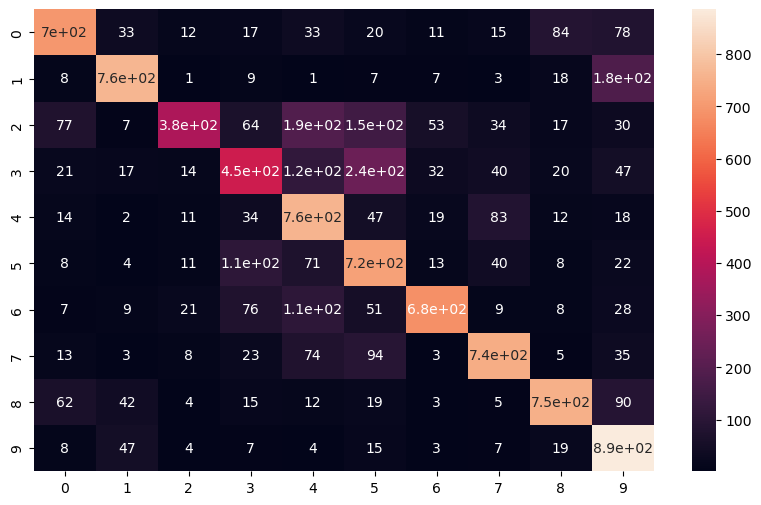

### Following code makes a prediction on specific image.

____________________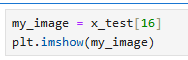

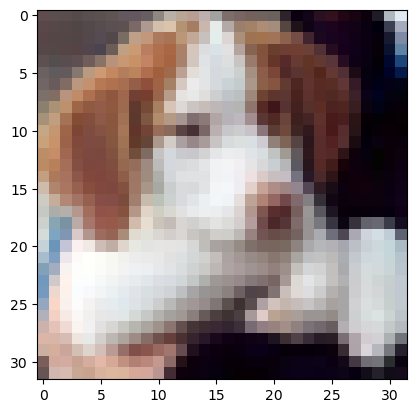

In [69]:
my_image =x_test[16]
plt.imshow(my_image)

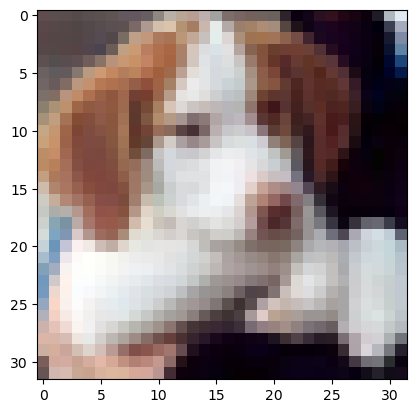

In [70]:
my_image = x_test[16]
plt.imshow(my_image)

______________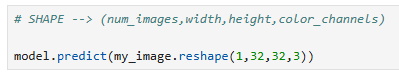

In [71]:
model.predict(my_image.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[6.7328806e-06, 1.9679414e-05, 8.1599166e-05, 9.1509998e-04,
        3.8291525e-08, 9.9891710e-01, 2.6139237e-06, 7.7643745e-06,
        2.4642044e-05, 2.4791749e-05]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


array([[1.13101294e-07, 3.55311378e-04, 8.73138470e-06, 8.25540442e-03,
        4.04348157e-07, 9.91317272e-01, 2.81208969e-07, 4.03509657e-05,
        4.70231180e-06, 1.75437362e-05]], dtype=float32)

In [137]:
# Find the highest probability value in the vector above. 
# What output value does it point to?

_______________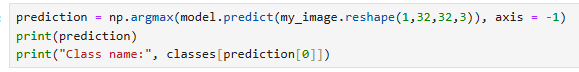

In [73]:
prediction = np.argmax(model.predict(my_image.reshape(1,32,32,3)), axis = -1)
print(prediction)
print("Class Name", classes[prediction[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[5]
Class Name dog


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
[5]
Class name: dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


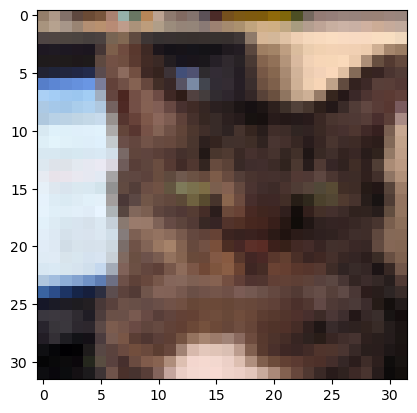

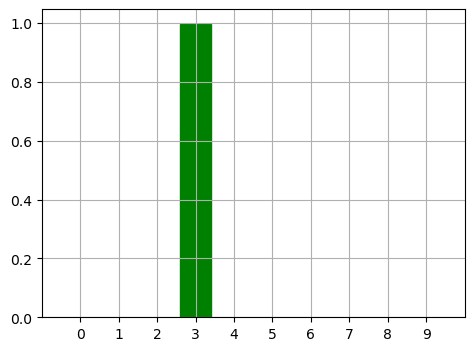

The predicted answer: cat 
 Correct answer: cat
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [76]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

In [77]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,340,480 (5.11 MB)

 Trainable params: 446,826 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 893,654 (3.41 MB)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends.

### 3. Based on this analysis, determine the optimal number of epochs for training your model. 

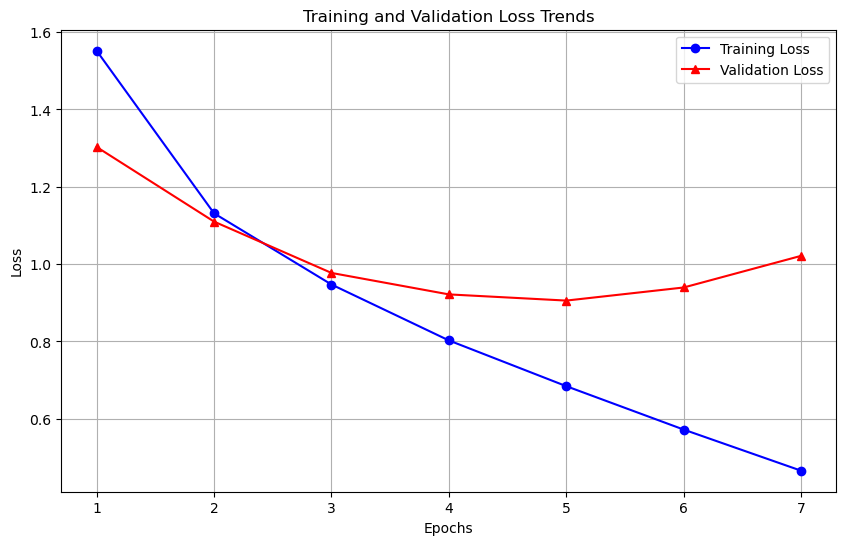

In [78]:
import matplotlib.pyplot as plt

# Extract data from the history object
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, 'bo-', label='Training Loss') # 'bo' is blue dot
plt.plot(epochs, val_loss_values, 'r^-', label='Validation Loss') # 'r^' is red triangle
plt.title('Training and Validation Loss Trends')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
pip install pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras. 

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [3]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser 

In [33]:
# From your existing code in Cell 68
model.summary()

# To generate the required plot for your logbook:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_summary_plot.png', show_shapes=True, show_layer_names=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,340,480 (5.11 MB)

 Trainable params: 446,826 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 893,654 (3.41 MB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


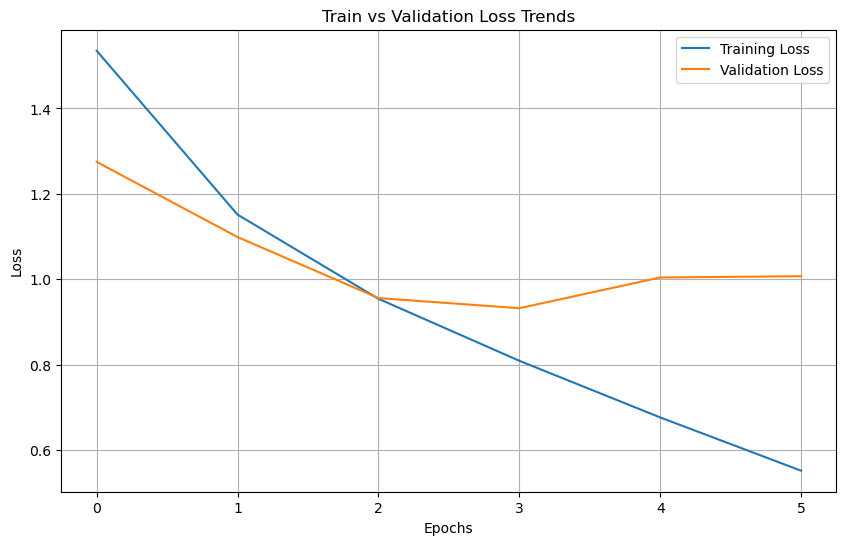

In [34]:
import matplotlib.pyplot as plt

# Using the 'history' variable from Cell 82/85
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Train vs Validation Loss Trends')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

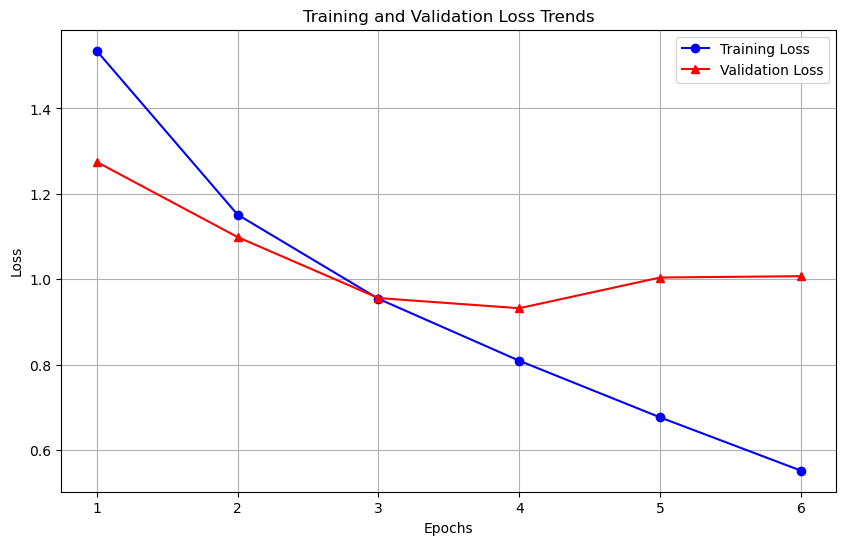

In [35]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, 'bo-', label='Training Loss') 
plt.plot(epochs, val_loss_values, 'r^-', label='Validation Loss') 
plt.title('Training and Validation Loss Trends')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Check layer shapes manually to help you draw the plot if needed
for layer in model.layers:
    print(f"Layer: {layer.name} | Input Shape: {layer.input_shape} | Output Shape: {layer.output_shape}")

AttributeError: 'Conv2D' object has no attribute 'input_shape'